In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
test_inf = pd.read_csv('fraudTest.csv')
train_inf = pd.read_csv('fraudTrain.csv')
train_inf

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [2]:
test_inf

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [3]:
df = pd.concat([train_inf, test_inf], ignore_index=True)
print(f"Объединенный датасет: {df.shape}")

Объединенный датасет: (1852394, 23)


In [4]:
for col in df.columns:
    print(f"{col}")

Unnamed: 0
trans_date_trans_time
cc_num
merchant
category
amt
first
last
gender
street
city
state
zip
lat
long
city_pop
job
dob
trans_num
unix_time
merch_lat
merch_long
is_fraud


In [7]:
cols_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'job', 'dob', 'trans_num', 'merchant']
df = df.drop(columns=cols_to_drop, errors='ignore')

In [8]:
fraud_counts = df['is_fraud'].value_counts()
print(f"Не мошенничество (0): {fraud_counts[0]:,} ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"Мошенничество (1):   {fraud_counts[1]:,} ({fraud_counts[1]/len(df)*100:.2f}%)")

Не мошенничество (0): 1,842,743 (99.48%)
Мошенничество (1):   9,651 (0.52%)


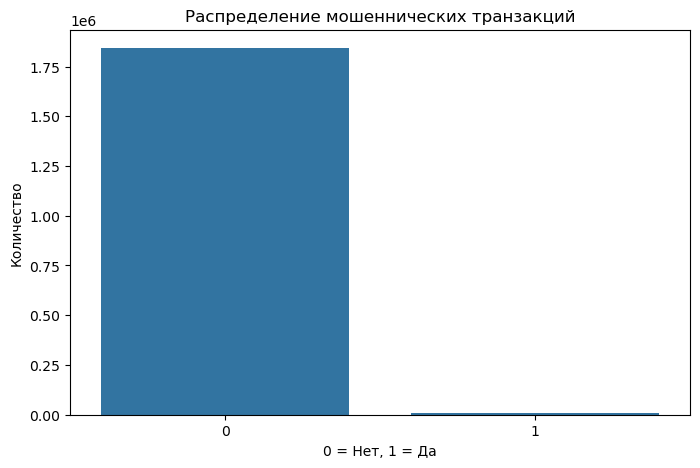

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='is_fraud')
plt.title('Распределение мошеннических транзакций')
plt.xlabel('0 = Нет, 1 = Да')
plt.ylabel('Количество')
plt.show()

In [10]:
print(f"Средняя сумма: ${df['amt'].mean():.2f}")
print(f"Максимальная сумма: ${df['amt'].max():.2f}")
print(f"Минимальная сумма: ${df['amt'].min():.2f}")

fraud_amt = df[df['is_fraud']==1]['amt']
legit_amt = df[df['is_fraud']==0]['amt']
print(f"Средняя сумма при мошенничестве: ${fraud_amt.mean():.2f}")
print(f"Средняя сумма в норме: ${legit_amt.mean():.2f}")

Средняя сумма: $70.06
Максимальная сумма: $28948.90
Минимальная сумма: $1.00
Средняя сумма при мошенничестве: $530.66
Средняя сумма в норме: $67.65


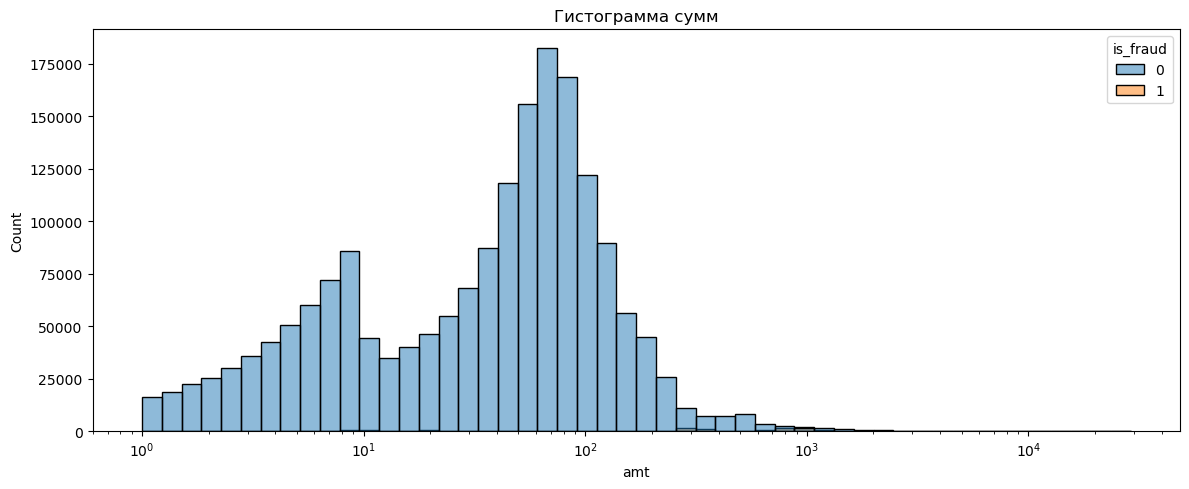

In [12]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='amt', hue='is_fraud', bins=50, log_scale=True)
plt.title('Гистограмма сумм')
plt.tight_layout()
plt.show()

category
grocery_pos      2228
shopping_net     2219
misc_net         1182
shopping_pos     1056
gas_transport     772
misc_pos          322
kids_pets         304
entertainment     292
personal_care     290
home              265
Name: count, dtype: int64


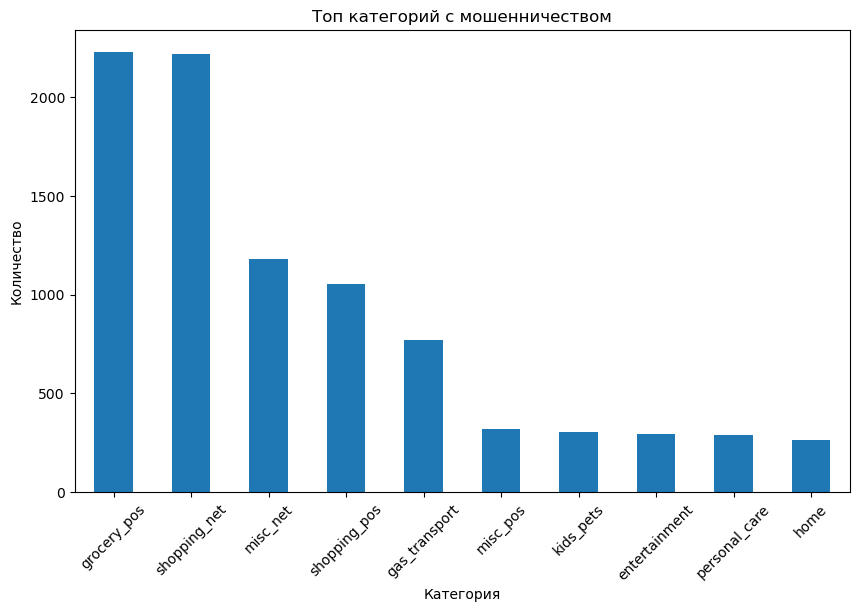

In [13]:
fraud_by_categ = df[df['is_fraud']==1]['category'].value_counts().head(10)
print(fraud_by_categ)

plt.figure(figsize=(10,6))
fraud_by_categ.plot(kind='bar')
plt.title('Топ категорий с мошенничеством')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

0    0
1    0
2    0
3    0
4    0
Name: hour, dtype: int32
hour
0    823
1    827
2    793
3    803
4     61
5     80
6     54
7     72
8     59
9     61
Name: count, dtype: int64


Text(0.5, 1.0, 'Мошенничество по часам')

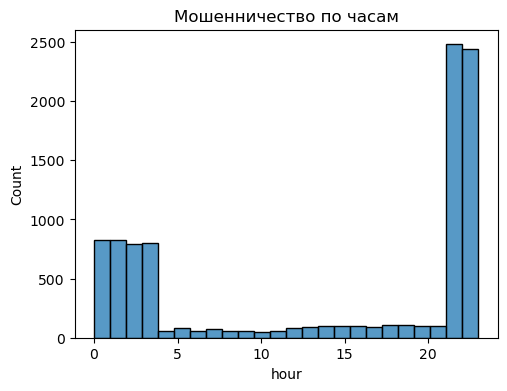

In [15]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
print(df['hour'].head())

by_hour = df[df['is_fraud']==1]['hour'].value_counts().sort_index()
print(by_hour.head(10))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=df[df['is_fraud']==1], x='hour', bins=24)
plt.title('Мошенничество по часам')

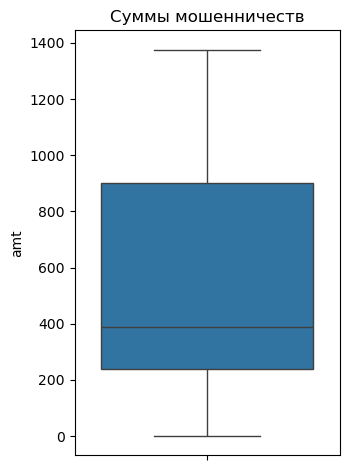

In [16]:
plt.subplot(1,2,2)
sns.boxplot(data=df[df['is_fraud']==1], y='amt')
plt.title('Суммы мошенничеств')
plt.tight_layout()
plt.show()

In [17]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

df['distance_km'] = df.apply(
    lambda row: haversine(row['lat'], row['long'], 
                          row['merch_lat'], row['merch_long']), 
    axis=1)

print("Статистика расстояний при мошенничестве:")
print(df[df['is_fraud']==1]['distance_km'].describe())

Статистика расстояний при мошенничестве:
count    9651.000000
mean       76.256233
std        28.865545
min         0.738769
25%        55.573136
50%        78.101922
75%        98.418296
max       144.522410
Name: distance_km, dtype: float64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


features = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 
            'hour', 'distance_km', 'category', 'gender']

enc_category = LabelEncoder()
enc_gender = LabelEncoder()

df['category_encoded'] = enc_category.fit_transform(df['category'])
df['gender_encoded'] = enc_gender.fit_transform(df['gender'])

numeric_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'hour', 'distance_km']
X = df[numeric_cols + ['category_encoded', 'gender_encoded']].copy()
y = df['is_fraud']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Мошенничества в train: {y_train.sum()}")
print(f"Мошенничества в test: {y_test.sum()}")

Train: (1481915, 10), Test: (370479, 10)
Мошенничества в train: 7698
Мошенничества в test: 1953


In [20]:
if 'trans_date_trans_time' in df.columns:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month'] = df['trans_date_trans_time'].dt.month

In [21]:
import xgboost as xgb
from sklearn.metrics import classification_report

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=100,      
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      0.99      0.99    368526
           1       0.26      0.96      0.42      1953

    accuracy                           0.99    370479
   macro avg       0.63      0.97      0.70    370479
weighted avg       1.00      0.99      0.99    370479



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score
rf_model = RandomForestClassifier(
    n_estimators=100,           
    max_depth=10,               
    class_weight='balanced',    
    random_state=42,
    n_jobs=-1                   
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Recall: 0.9421
Precision: 0.2222
F1: 0.3596
ROC-AUC: 0.9946
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368526
           1       0.22      0.94      0.36      1953

    accuracy                           0.98    370479
   macro avg       0.61      0.96      0.68    370479
weighted avg       1.00      0.98      0.99    370479



In [24]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

mlp_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),  
    max_iter=30,                   
#    batch_size=1024,              
    random_state=42
)


mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_proba_mlp = mlp_model.predict_proba(X_test)[:, 1]

print(f"Recall: {recall_score(y_test, y_pred_mlp):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_mlp):.4f}")
print(f"F1: {f1_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Recall: 0.6513
Precision: 0.8766
F1: 0.7474
ROC-AUC: 0.9914
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368526
           1       0.88      0.65      0.75      1953

    accuracy                           1.00    370479
   macro avg       0.94      0.83      0.87    370479
weighted avg       1.00      1.00      1.00    370479



In [25]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    scale_pos_weight=200,        
    random_seed=42,
    iterations=50,
    depth=5,
    learning_rate=0.1,
    verbose=False,
    thread_count=-1
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

print(f"Recall: {recall_score(y_test, y_pred_cat):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cat):.4f}")
print(f"F1: {f1_score(y_test, y_pred_cat):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cat):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_cat))

Recall: 0.9514
Precision: 0.1188
F1: 0.2113
ROC-AUC: 0.9924
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    368526
           1       0.12      0.95      0.21      1953

    accuracy                           0.96    370479
   macro avg       0.56      0.96      0.60    370479
weighted avg       1.00      0.96      0.98    370479



In [26]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=200,       
    random_state=42,
    n_estimators=50,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print(f"Recall:{recall_score(y_test, y_pred_lgb):.4f}")
print(f"Precision:{precision_score(y_test, y_pred_lgb):.4f}")
print(f"F1:{f1_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba_lgb):.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_lgb))

Recall:0.9232
Precision:0.0447
F1:0.0853
ROC-AUC:0.9153
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.94    368526
           1       0.04      0.92      0.09      1953

    accuracy                           0.90    370479
   macro avg       0.52      0.91      0.51    370479
weighted avg       0.99      0.90      0.94    370479



In [27]:
models = {
    'CatBoost': cat_model,
    'XGBoost': xgb_model,
    'RandomForest': rf_model,
    'LightGBM': lgb_model,
    'MLP': mlp_model
}


results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Модель': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('F1', ascending=False)

print(df_results.to_string(index=False))

      Модель   Recall  Precision       F1  ROC-AUC
         MLP 0.651306   0.876637 0.747356 0.991444
     XGBoost 0.958525   0.264931 0.415124 0.997495
RandomForest 0.942140   0.222195 0.359586 0.994621
    CatBoost 0.951357   0.118821 0.211256 0.992392
    LightGBM 0.923195   0.044714 0.085297 0.915299


In [29]:
top5_models = df_results.head(5).copy()
print(top5_models[['Модель', 'Recall', 'Precision', 'F1', 'ROC-AUC']].to_string(index=False))

      Модель   Recall  Precision       F1  ROC-AUC
     XGBoost 0.958525   0.264931 0.415124 0.997495
         MLP 0.651306   0.876637 0.747356 0.991444
RandomForest 0.942140   0.222195 0.359586 0.994621
    CatBoost 0.951357   0.118821 0.211256 0.992392
    LightGBM 0.923195   0.044714 0.085297 0.915299


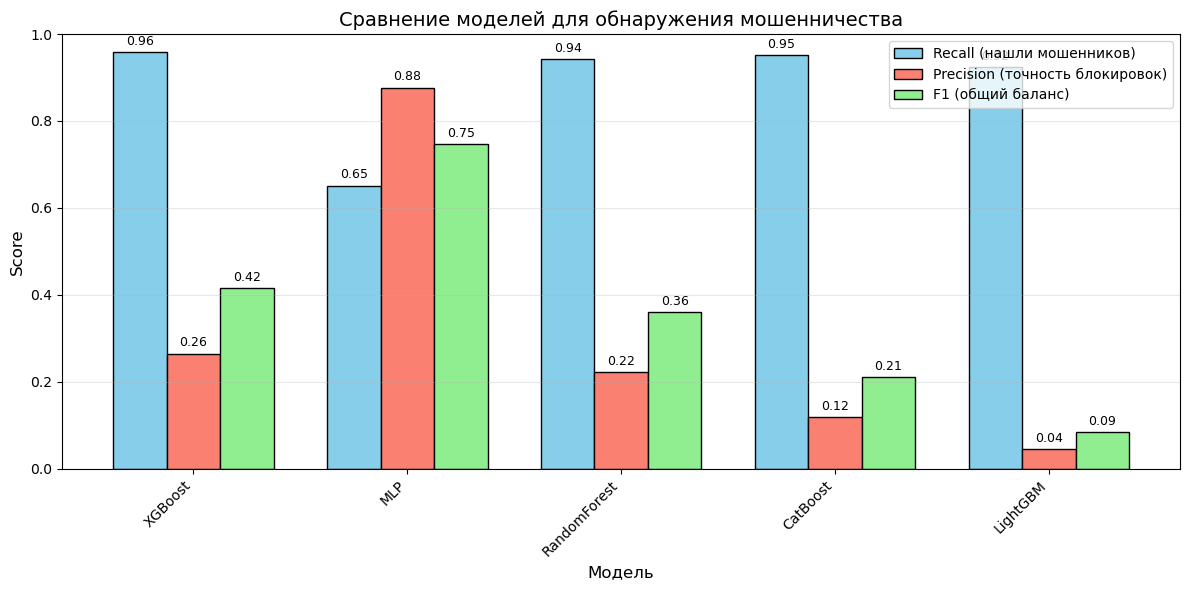

In [30]:
top5_models = df_results.head(5).copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top5_models))
width = 0.25

bars1 = ax.bar(x - width, top5_models['Recall'], width, label='Recall (нашли мошенников)', color='skyblue', edgecolor='black')
bars2 = ax.bar(x, top5_models['Precision'], width, label='Precision (точность блокировок)', color='salmon', edgecolor='black')
bars3 = ax.bar(x + width, top5_models['F1'], width, label='F1 (общий баланс)', color='lightgreen', edgecolor='black')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', 
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3), 
                   textcoords="offset points", 
                   ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Сравнение моделей для обнаружения мошенничества', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top5_models['Модель'], rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import joblib

# Подготовка данных
feature_names = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'hour', 'distance_km']
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

# Препроцессор
preprocessor = ColumnTransformer([('num', StandardScaler(), feature_names)])

# АНСАМБЛЬ (ПРАВИЛЬНЫЕ ПАРАМЕТРЫ ДЛЯ ВЫСОКОГО RECALL)
ensemble_5 = VotingClassifier(
    estimators=[
        ('catboost', CatBoostClassifier(
            scale_pos_weight=200, 
            iterations=100,        
            depth=6,
            verbose=False,
            random_seed=42
        )),
        ('xgb', xgb.XGBClassifier(
            scale_pos_weight=200, 
            n_estimators=100,      
            max_depth=6,
            eval_metric='logloss',
            random_state=42
        )),
        ('rf', RandomForestClassifier(
            n_estimators=100,      
            max_depth=10,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )),
        ('lgb', lgb.LGBMClassifier(
            scale_pos_weight=200, 
            n_estimators=100,      
            max_depth=10,
            verbose=-1,
            random_state=42
        )),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 32),  # было (64,32)
            max_iter=50,                  # было 50
            random_state=42
        ))
    ],
    voting='soft',
    weights=[2, 2, 2, 1, 1]  
)

# Пайплайн
ensemble_pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', ensemble_5)])

# Обучение
ensemble_pipeline.fit(X_train, y_train)

# Сохранение
joblib.dump(ensemble_pipeline, 'ensemble_my_models.pkl')

y_proba = ensemble_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.5).astype(int)

print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Recall: 0.9037
Precision: 0.1122
F1: 0.1997
ROC-AUC: 0.9852


In [61]:
import joblib

# Загружаем вашу модель из существующего файла
model = joblib.load('ensemble_5_models.pkl')

# Сохраняем под новым именем
joblib.dump(model, 'ensemble_my_models.pkl')

print("Файл ensemble_my_models.pkl создан!")


import os
size_mb = os.path.getsize('ensemble_my_models.pkl') / (1024 * 1024)
print(f"Размер: {size_mb:.1f} МБ")

✅ Файл ensemble_my_models.pkl создан!
Размер: 5.6 МБ
